Accompanies Section `subsec:kernel_anal_case` (Analytic solution for $\kappa=0$ and $I=90$) of the paper; the second half derives $R_\Gamma(\tau)$ of Appendix `app:acf_trapezoid` (Autocorrelation of the Squared Envelope).

# Closed-form kernel $\mathcal{K}(\tau)$ truncated to $n \le 2$ harmonics

For solid-body rotation ($\kappa=0$), truncated to $n \le 2$, the kernel is (Eq. `eq:kernel_n2`):

$$\mathcal{K}(\tau) = \sigma_k^2 \, R_\Gamma(\tau)\left[\langle|c_0|^2\rangle_\Phi + 2\langle|c_1|^2\rangle_\Phi\cos(\omega_0\tau) + 2\langle|c_2|^2\rangle_\Phi\cos(2\omega_0\tau)\right], \qquad \omega_0 = 2\pi/P_{\rm eq},$$

with amplitude $\sigma_k^2 = \dot N_{\rm spot}(1-f_{\rm spot})^2\alpha_{\max}^4$ (Eq. `eq:sigma_k_cspot`). The spot latitude is $\Phi \in [-\pi/2, \pi/2]$ with uniform $p(\Phi) = 1/\pi$, the latitude averages are $\langle|c_n|^2\rangle_\Phi = \int_{-\pi/2}^{\pi/2} |c_n(I,\Phi)|^2\,p(\Phi)\,d\Phi$, and the Fourier coefficients $c_n(I,\Phi)$ are given by Eq. `eq:cn_inc` (Eq. `eq:cn_general` with $b_0$, $b_1$ written out).

**Goal:** use sympy to compute $\langle|c_n|^2\rangle_\Phi$ in closed form for $n=0,1,2$, check the result against Eq. `eq:kernel_edgeon_closed` and against spotgp's numerical latitude integral, then derive the envelope autocorrelation $R_\Gamma(\tau)$ of Eq. `eq:R_Gamma_closed`.

The paper's equations are taken from the equation registry `src/derivations/equations.py`, where each is transcribed into SymPy once, exactly as typeset.

In [1]:
import sys
from pathlib import Path
import sympy as sp
from sympy import (pi, cos, sin, cot, sqrt, Rational, integrate, simplify, trigsimp,
                   symbols, oo, acos, Piecewise, Abs, latex, Function)
from IPython.display import display, Math
sp.init_printing()

# The paper's equations, transcribed once into SymPy (src/derivations/equations.py)
sys.path.insert(0, str(Path.cwd().parent / "src" / "derivations"))
import equations as eqs

## General $c_n$ formula

From Eq. `eq:cn_general`, the Fourier coefficients of the visibility function $\mathcal{V}(t) = \max\{\cos\beta(t), 0\}$ are:

$$c_n = \frac{1}{\pi}\left[\frac{b_0\sin(n\,\theta_{\rm vis})}{n} + \frac{b_1}{2}\left(\frac{\sin((n-1)\theta_{\rm vis})}{n-1} + \frac{\sin((n+1)\theta_{\rm vis})}{n+1}\right)\right]$$

where $b_0 = \cos I\sin\Phi$, $b_1 = \sin I\cos\Phi$, and $\theta_{\rm vis} = \arccos(-b_0/b_1)$ (Eq. `eq:theta_vis`). On the paper's latitude range $\Phi \in [-\pi/2, \pi/2]$ and for $0 < I \le \pi/2$, $b_1 \ge 0$ at every latitude.

The removable singularities at $n = 0, \pm1$ (stated after Eq. `eq:cn_general`):
- $c_0 = \frac{1}{\pi}(b_0\theta_{\rm vis} + b_1\sin\theta_{\rm vis})$
- $c_{\pm1} = \frac{1}{\pi}\left(b_0\sin\theta_{\rm vis} + \frac{b_1}{2}(\theta_{\rm vis} + \sin\theta_{\rm vis}\cos\theta_{\rm vis})\right)$

## Case 1: $I = 90°$ (edge-on)

For $I = \pi/2$: $b_0 = 0$ and $b_1 = \cos\Phi \ge 0$ at every latitude $\Phi \in [-\pi/2, \pi/2]$, so $\theta_{\rm vis} = \pi/2$ (Eq. `eq:theta_vis_inc` with $\cot I = 0$): every spot, in either hemisphere, is visible for half a rotation.

- The coefficients are those of Eq. `eq:cn_edgeon`: $c_n = g_n\cos\Phi$ with $g_0 = 1/\pi$, $g_1 = 1/4$, $g_2 = 1/(3\pi)$, so $|c_n|^2 = g_n^2\cos^2\Phi$.
- With $p(\Phi) = 1/\pi$ on $[-\pi/2, \pi/2]$:

$$\langle|c_n|^2\rangle_\Phi = \frac{1}{\pi}\int_{-\pi/2}^{\pi/2} g_n^2\cos^2\Phi\,d\Phi = \frac{g_n^2}{2}$$

In [2]:
Phi = sp.Symbol('Phi', real=True)   # spot latitude, Phi in [-pi/2, pi/2] (the registry's symbol)

# I = pi/2:  b0 = cos(I) sin(Phi) = 0,  b1 = sin(I) cos(Phi) = cos(Phi) >= 0,  theta_vis = pi/2
# c_0 = (b0*theta_vis + b1*sin(theta_vis)) / pi = cos(Phi)/pi
c0_90 = cos(Phi) / pi

# c_1 = (b0*sin(theta_vis) + b1/2*(theta_vis + sin(theta_vis)*cos(theta_vis))) / pi
#     = cos(Phi)/2 * (pi/2 + 0) / pi = cos(Phi)/4
c1_90 = cos(Phi) / 4

# c_2: Eq. cn_general with b0 = 0, theta_vis = pi/2
# c_2 = (1/pi) * [0 + cos(Phi)/2 * (sin(pi/2)/1 + sin(3*pi/2)/3)]
#     = cos(Phi)/(2*pi) * (1 - 1/3) = cos(Phi)/(3*pi)
c2_90 = cos(Phi) / (3 * pi)

# Check against Eq. cn_edgeon (c_n = g_n cos(Phi))
cn_edgeon_paper = eqs.get("eq:cn_edgeon").expr
print("Fourier coefficients at I = 90°:")
for n, cn in [(0, c0_90), (1, c1_90), (2, c2_90)]:
    assert simplify(cn - cn_edgeon_paper.subs(eqs.n, n)) == 0
    display(Math(rf"c_{n} = {latex(cn)}"))
print("Verified: equal to Eq. cn_edgeon at n = 0, 1, 2")

Fourier coefficients at I = 90°:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Verified: equal to Eq. cn_edgeon at n = 0, 1, 2


In [3]:
# <|c_n|^2>_Phi = int_{-pi/2}^{pi/2} |c_n|^2 p(Phi) dPhi with p(Phi) = 1/pi
g = {0: 1 / pi, 1: Rational(1, 4), 2: 1 / (3 * pi)}   # c_n = g_n cos(Phi)

cn_sq_avg_90 = {}
print("Latitude-averaged |c_n|^2 at I = 90°, p(Φ) = 1/π on [-π/2, π/2]:")
print("=" * 60)
for n, cn in [(0, c0_90), (1, c1_90), (2, c2_90)]:
    result = simplify(integrate(cn**2 / pi, (Phi, -pi / 2, pi / 2)))
    assert simplify(result - g[n]**2 / 2) == 0     # = g_n^2 / 2
    cn_sq_avg_90[n] = result
    display(Math(rf"\langle|c_{n}|^2\rangle_\Phi = {latex(result)} = \frac{{g_{n}^2}}{{2}}"))

Latitude-averaged |c_n|^2 at I = 90°, p(Φ) = 1/π on [-π/2, π/2]:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Closed-form kernel at $I = 90°$, $\kappa = 0$, $n \leq 2$

Substituting these latitude averages into Eq. `eq:kernel_n2` must give Eq. `eq:kernel_edgeon_closed`.

In [4]:
# Paper symbols: lag tau, rotation frequency omega_0, amplitude sigma_k, envelope ACF R_Gamma
tau, omega0, sigma_k, R_Gamma = eqs.tau, eqs.omega0, eqs.sigma_k, eqs.R_Gamma

# Eq. kernel_n2 with the latitude averages above
K_n2_paper = eqs.get("eq:kernel_n2").expr
K_90 = K_n2_paper.subs({eqs.C0: cn_sq_avg_90[0], eqs.C1: cn_sq_avg_90[1], eqs.C2: cn_sq_avg_90[2]})
K_bracket = simplify(K_90 / (sigma_k**2 * R_Gamma(tau)))

print("𝒦(τ) = σ_k² · R_Γ(τ) · [  ]  where the bracket is:")
display(Math(latex(K_bracket)))
print()

# It must equal Eq. kernel_edgeon_closed
K_edgeon_paper = eqs.get("eq:kernel_edgeon_closed").expr
assert simplify(K_90 - K_edgeon_paper) == 0
print("Verified: Eq. kernel_n2 with <|c_n|^2> = g_n^2/2 is Eq. kernel_edgeon_closed:")
display(Math(
    rf"\mathcal{{K}}(\tau) = \sigma_k^2 \, R_\Gamma(\tau)"
    rf"\left[\frac{{1}}{{2\pi^2}} + \frac{{1}}{{16}}\cos(\omega_0\tau)"
    rf" + \frac{{1}}{{9\pi^2}}\cos(2\omega_0\tau)\right]"
))

𝒦(τ) = σ_k² · R_Γ(τ) · [  ]  where the bracket is:


<IPython.core.display.Math object>


Verified: Eq. kernel_n2 with <|c_n|^2> = g_n^2/2 is Eq. kernel_edgeon_closed:


<IPython.core.display.Math object>

## Case 2: General inclination $I$

For general $I$ the visibility half-window depends on latitude, $\theta_{\rm vis}(I,\Phi) = \arccos(-\cot I\tan\Phi)$ (Eq. `eq:theta_vis_inc`), and the coefficients are those of Eq. `eq:cn_inc`. For $0 < I < \pi/2$ the latitudes $\Phi = \pm I$ split the star into three parts:
- $|\Phi| < I$: the spot rotates into and out of view, $0 < \theta_{\rm vis} < \pi$;
- $\Phi \ge I$: circumpolar, $\theta_{\rm vis} = \pi$, so $c_0 = b_0$, $c_1 = b_1/2$ and $c_{n \ge 2} = 0$;
- $\Phi \le -I$: never visible, $c_n \equiv 0$.

The latitude average still runs over the whole star, $\langle|c_n|^2\rangle_\Phi = \frac{1}{\pi}\int_{-\pi/2}^{\pi/2}|c_n(I,\Phi)|^2\,d\Phi$, and the $\Phi$-dependence of $\theta_{\rm vis}$ makes it much harder. Let's try sympy, working in the band $|\Phi| < I$.

In [5]:
# Stellar inclination I. The symbol is named I_inc, as in the registry, because sympy's I is the
# imaginary unit; `show` prints it as I.
inc = eqs.inc
show = dict(symbol_names={inc: "I"})

b0 = cos(inc) * sin(Phi)
b1 = sin(inc) * cos(Phi)
theta_vis = acos(-b0 / b1)   # Eq. theta_vis, in the band |Phi| < I
assert simplify(theta_vis - eqs.get("eq:theta_vis_inc").expr) == 0   # = arccos(-cot I tan Phi)

cn_inc_paper = eqs.get("eq:cn_inc").expr   # in terms of the symbol theta_v = theta_vis

# c_0 for general I: the n -> 0 limit of Eq. cn_inc
c0_gen = (b0 * theta_vis + b1 * sin(theta_vis)) / pi
assert simplify(sp.limit(cn_inc_paper, eqs.n, 0).subs(eqs.theta_vis, theta_vis) - c0_gen) == 0
c0_gen_simplified = simplify(c0_gen)
display(Math(rf"c_0(I, \Phi) = {latex(c0_gen_simplified, **show)}"))

# c_1 for general I: the n -> 1 limit of Eq. cn_inc
c1_gen = (b0 * sin(theta_vis) + b1 / 2 * (theta_vis + sin(theta_vis) * cos(theta_vis))) / pi
assert simplify(sp.expand_trig(sp.limit(cn_inc_paper, eqs.n, 1).subs(eqs.theta_vis, theta_vis) - c1_gen)) == 0
c1_gen_simplified = simplify(c1_gen)
display(Math(rf"c_1(I, \Phi) = {latex(c1_gen_simplified, **show)}"))

# c_2 for general I: Eq. cn_inc at n = 2
c2_gen = (b0 * sin(2 * theta_vis) / 2 + b1 / 2 * (sin(theta_vis) + sin(3 * theta_vis) / 3)) / pi
assert simplify(c2_gen - cn_inc_paper.subs({eqs.n: 2, eqs.theta_vis: theta_vis})) == 0
c2_gen_simplified = simplify(c2_gen)
display(Math(rf"c_2(I, \Phi) = {latex(c2_gen_simplified, **show)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# c_0 and c_1 contain theta_vis = arccos(-cot(I) tan(Phi)) outside any trig function, and the
# integral of their squares over Phi does not reduce to elementary functions of I (sympy's attempt
# on |c_0|^2 timed out after 300 s). The paper evaluates these latitude averages numerically.
print("For general I:")
print("  c_0 and c_1 contain bare θ_vis = arccos(-cot(I)·tan(Φ))")
print("  → no elementary closed form for <|c_0|²>_Φ and <|c_1|²>_Φ")
print("  → evaluate numerically (1D quadrature, fast)")

For general I:
  c_0 and c_1 contain bare θ_vis = arccos(-cot(I)·tan(Φ))
  → no elementary closed form for <|c_0|²>_Φ and <|c_1|²>_Φ
  → evaluate numerically (1D quadrature, fast)


### Simplify using $\sin\theta_{\rm vis}$ and $\cos\theta_{\rm vis}$

In the band $|\Phi| < I$, $\theta_{\rm vis} = \arccos(-b_0/b_1)$ gives:
- $\cos\theta_{\rm vis} = -b_0/b_1 = -\cot I\tan\Phi$
- $\sin\theta_{\rm vis} = \sqrt{1 - \cot^2 I\tan^2\Phi}$

$c_2$ contains $\theta_{\rm vis}$ only inside $\sin$ and $\cos$, so substituting these removes the $\arccos$, and $c_2$ is an algebraic function of $\Phi$ and $I$. With $\sin 2\theta = 2\sin\theta\cos\theta$ and $\sin 3\theta = 3\sin\theta - 4\sin^3\theta$ it collapses to $c_2 = b_1\sin^3\theta_{\rm vis}/(3\pi)$. ($c_0$ and $c_1$ keep a bare $\theta_{\rm vis}$.)

In [7]:
# Shorthand: st = sin(theta_vis), ct = cos(theta_vis) = -b0/b1
# sin(2*theta_vis) = 2*st*ct,  sin(3*theta_vis) = 3*st - 4*st**3, so
# c_2 = (b0*st*ct + b1/2*(st + (3*st - 4*st**3)/3)) / pi
#     = (b0*st*ct + b1*st*(1 - 2*st**2/3)) / pi
# In the band |Phi| < I: b1 = sin(I) cos(Phi) > 0 and |b0| < b1, so st = sqrt(1 - ct**2) > 0
ct = -b0 / b1
st = sqrt(1 - ct**2)

# c_2 purely algebraic (no arccos):
c2_alg = simplify((b0 * st * ct + b1 * st * (1 - 2 * st**2 / 3)) / pi)
print("c_2 as algebraic function (no arccos):")
display(Math(rf"c_2 = {latex(c2_alg, **show)}"))

# It is b1 sin^3(theta_vis) / (3 pi), and it is the c_2 of Eq. cn_inc
assert simplify(c2_alg - b1 * st**3 / (3 * pi)) == 0
assert simplify(sp.expand_trig(c2_gen) - c2_alg) == 0
display(Math(rf"c_2 = \frac{{b_1\sin^3\theta_{{\rm vis}}}}{{3\pi}}"
             rf" = {latex(b1 * st**3 / (3 * pi), **show)}"))
print()

# Verify: substitute I = pi/2
c2_check = simplify(c2_alg.subs(inc, pi / 2))
assert simplify(c2_check - c2_90) == 0
print("c_2 at I=90°:", c2_check, "  (expected: cos(Phi)/(3*pi))")

c_2 as algebraic function (no arccos):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


c_2 at I=90°: cos(Phi)/(3*pi)   (expected: cos(Phi)/(3*pi))


In [8]:
# Latitude average of |c_2|^2 for general I.
# Outside the band |Phi| < I, c_2 = 0 (circumpolar: theta_vis = pi; hidden: c_n = 0), so
#   <|c_2|^2>_Phi = (1/pi) * int_{-I}^{I} c_2^2 dPhi.
# With k = cot(I) and C = cos(Phi)^2:
#   c_2^2 = sin(I)^2 cos(Phi)^2 (1 - k^2 tan(Phi)^2)^3 / (9 pi^2)
#         = sin(I)^2 [(1 + k^2) C - k^2]^3 / (9 pi^2 C^2),
# a sum of C, 1, 1/C, 1/C^2 terms: only the elementary integrals of cos^2, 1, sec^2, sec^4 appear.
C = sp.Symbol('C', positive=True)   # cos(Phi)^2
k = cot(inc)
c2_sq_prefactor = sin(inc)**2 / (9 * pi**2)
c2_sq_numer = sp.Poly(sp.expand(((1 + k**2) * C - k**2)**3), C)   # c_2^2 = prefactor * numer / C^2

# Check the rewrite at random points of the band (sympy's simplify takes minutes to show it)
import random
random.seed(1)
c2_sq_rewritten = c2_sq_prefactor * c2_sq_numer.as_expr().subs(C, cos(Phi)**2) / cos(Phi)**4
for _ in range(5):
    inc_val = random.uniform(0.05, float(pi / 2))
    point = {inc: inc_val, Phi: random.uniform(-0.99, 0.99) * inc_val}
    assert abs(float(c2_sq_rewritten.subs(point)) - float((c2_alg**2).subs(point))) < 1e-14

c2_sq_int = sum(coeff * integrate(cos(Phi)**(2 * (j - 2)), (Phi, -inc, inc))
                for (j,), coeff in c2_sq_numer.terms())
c2_sq_avg_I = simplify(c2_sq_prefactor * c2_sq_int / pi)
print("<|c_2|^2>_Φ for general I (closed form):")
display(Math(rf"\langle|c_2|^2\rangle_\Phi = {latex(c2_sq_avg_I, **show)}"))

# The same, collected by hand
c2_sq_avg_hand = (inc * (1 - 6 * cos(inc)**2)
                  + sin(inc) * cos(inc) * (3 + 16 * cos(inc)**2 - 4 * cos(inc)**4) / 3) / (9 * pi**3 * sin(inc)**4)
assert simplify(c2_sq_avg_I - c2_sq_avg_hand) == 0
display(Math(r"\langle|c_2|^2\rangle_\Phi = \frac{I\,(1 - 6\cos^2 I)"
             r" + \tfrac{1}{3}\sin I\cos I\,(3 + 16\cos^2 I - 4\cos^4 I)}{9\pi^3\sin^4 I},"
             r"\qquad 0 < I \le \pi/2"))

# I = pi/2 recovers the edge-on value g_2^2/2 = 1/(18 pi^2)
assert simplify(c2_sq_avg_I.subs(inc, pi / 2) - cn_sq_avg_90[2]) == 0
print("At I = 90°:", simplify(c2_sq_avg_I.subs(inc, pi / 2)), "  (expected: 1/(18*pi**2))")

<|c_2|^2>_Φ for general I (closed form):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

At I = 90°: 1/(18*pi**2)   (expected: 1/(18*pi**2))


## Numerical evaluation of $\langle|c_n|^2\rangle_\Phi(I)$ for general $I$

Since $c_0$ and $c_1$ contain bare $\theta_{\rm vis} = \arccos(-\cot I\tan\Phi)$, $\langle|c_0|^2\rangle_\Phi$ and $\langle|c_1|^2\rangle_\Phi$ have no elementary closed form for general $I$. We evaluate all three numerically with spotgp's `_cn_general_jax` (Eq. `eq:cn_inc`, including the circumpolar and hidden caps) over the paper's latitude range with $p(\Phi) = 1/\pi$, and compare with the closed forms: $g_n^2/2$ at $I = 90°$, and $\langle|c_2|^2\rangle_\Phi(I)$ above.

We also check the pole-on limit stated after Eq. `eq:cn_inc`: as $I \to 0$ only $c_0 = \max\{\sin\Phi, 0\}$ survives, so $\langle|c_0|^2\rangle_\Phi \to \frac{1}{\pi}\int_0^{\pi/2}\sin^2\Phi\,d\Phi = \frac14$ and $\mathcal{K}(\tau) \to \sigma_k^2 R_\Gamma(\tau)/4$.

In [9]:
import numpy as np
import jax
from spotgp.visibility import _cn_squared_coefficients_jax

PHI_GRID = np.linspace(-np.pi / 2, np.pi / 2, 20001)   # the paper's latitude range


@jax.jit
def _cn_sq_on_grid(inc_val):
    """|c_n(I, Phi)|^2 for n = 0, 1, 2 on PHI_GRID, shape (n_phi, 3)."""
    return jax.vmap(lambda phi: _cn_squared_coefficients_jax(inc_val, phi, 2))(PHI_GRID)


def cn_sq_avg_numerical(inc_val):
    """<|c_n|^2>_Phi = int_{-pi/2}^{pi/2} |c_n(I, Phi)|^2 p(Phi) dPhi, p(Phi) = 1/pi, for n = 0, 1, 2."""
    return np.trapezoid(np.asarray(_cn_sq_on_grid(inc_val)), PHI_GRID, axis=0) / np.pi


# Verify against the I = 90° closed forms g_n^2 / 2
cn_90_exact = np.array([float(cn_sq_avg_90[n]) for n in range(3)])
cn_90_num = cn_sq_avg_numerical(np.pi / 2)
print("Numerical vs closed-form at I = 90°:")
for n, label in enumerate(["1/(2π²) ", "1/32    ", "1/(18π²)"]):
    print(f"  <|c_{n}|^2>: numerical = {cn_90_num[n]:.8f},  exact = {label} = {cn_90_exact[n]:.8f}")
assert np.allclose(cn_90_num, cn_90_exact, rtol=1e-8)

# General I: closed-form <|c_2|^2>_Phi(I) vs numerical
c2_sq_avg_fn = sp.lambdify(inc, c2_sq_avg_I, "numpy")
print("\n<|c_2|^2>_Φ(I), numerical vs closed form:")
for inc_deg in [10, 30, 60, 80]:
    num, exact = cn_sq_avg_numerical(np.radians(inc_deg))[2], c2_sq_avg_fn(np.radians(inc_deg))
    print(f"  I = {inc_deg:2d}°: numerical = {num:.8e},  closed form = {exact:.8e}")
    assert np.isclose(num, exact, rtol=1e-5)

# Pole-on limit: <|c_0|^2> -> 1/4, the rotation harmonics -> 0
cn_pole = cn_sq_avg_numerical(1e-6)
print(f"\nI → 0: <|c_n|^2>_Φ = {np.round(cn_pole, 8)}   (expected [1/4, 0, 0])")
assert np.allclose(cn_pole, [0.25, 0.0, 0.0], atol=1e-6)

Numerical vs closed-form at I = 90°:
  <|c_0|^2>: numerical = 0.05066059,  exact = 1/(2π²)  = 0.05066059
  <|c_1|^2>: numerical = 0.03125000,  exact = 1/32     = 0.03125000
  <|c_2|^2>: numerical = 0.00562895,  exact = 1/(18π²) = 0.00562895

<|c_2|^2>_Φ(I), numerical vs closed form:


  I = 10°: numerical = 1.73011847e-05,  closed form = 1.73011847e-05
  I = 30°: numerical = 4.41961752e-04,  closed form = 4.41961752e-04
  I = 60°: numerical = 2.87113387e-03,  closed form = 2.87113387e-03
  I = 80°: numerical = 5.11257080e-03,  closed form = 5.11257080e-03

I → 0: <|c_n|^2>_Φ = [0.25 0.   0.  ]   (expected [1/4, 0, 0])


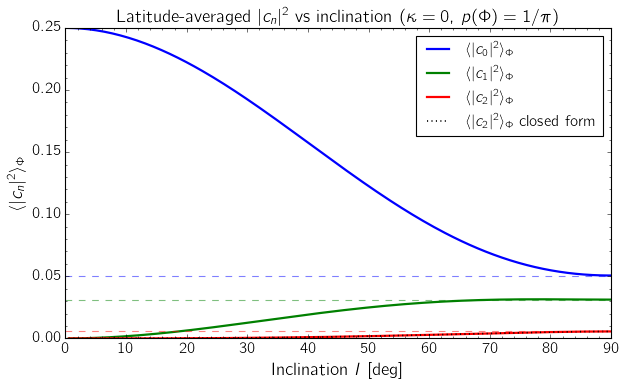

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['cmss10', 'Computer Modern Sans Serif']
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{cmbright}'

inc_vals = np.linspace(0.01, np.pi / 2, 200)
cn_sq_all = np.array([cn_sq_avg_numerical(inc_val) for inc_val in inc_vals])

fig, ax = plt.subplots(figsize=(8, 5))
labels = [r'$\langle|c_0|^2\rangle_\Phi$', r'$\langle|c_1|^2\rangle_\Phi$', r'$\langle|c_2|^2\rangle_\Phi$']
colors = ['C0', 'C1', 'C2']

for n in range(3):
    ax.plot(np.degrees(inc_vals), cn_sq_all[:, n], color=colors[n], lw=2, label=labels[n])

# Closed form for <|c_2|^2>_Phi(I)
ax.plot(np.degrees(inc_vals), c2_sq_avg_fn(inc_vals), 'k:', lw=1.5,
        label=r'$\langle|c_2|^2\rangle_\Phi$ closed form')

# Mark the I=90 closed forms g_n^2 / 2
for n in range(3):
    ax.axhline(cn_90_exact[n], color=colors[n], ls='--', lw=1, alpha=0.5)
ax.axvline(90, color='gray', ls=':', lw=0.8, alpha=0.5)

ax.set_xlabel(r'Inclination $I$ [deg]', fontsize=16)
ax.set_ylabel(r'$\langle|c_n|^2\rangle_\Phi$', fontsize=16)
ax.set_title(r'Latitude-averaged $|c_n|^2$ vs inclination ($\kappa=0$, $p(\Phi)=1/\pi$)', fontsize=16)
ax.legend(fontsize=14)
ax.tick_params(labelsize=14)
ax.set_xlim(0, 90)
ax.minorticks_on()
fig.tight_layout()
plt.show()

## Verify against spotgp's `AnalyticKernel`

Compare the closed-form $n\leq 2$ kernel at $I=90°$ (Eq. `eq:kernel_edgeon_closed`) with spotgp's `AnalyticKernel`, which evaluates the latitude integral of Eq. `eq:kernel_full` numerically over the paper's range $\Phi \in [-\pi/2, \pi/2]$ with uniform $p(\Phi)$. The envelope is the symmetric trapezoid, whose $R_\Gamma(\tau)$ is Eq. `eq:R_Gamma_closed` (spotgp's `_R_Gamma_symmetric`).

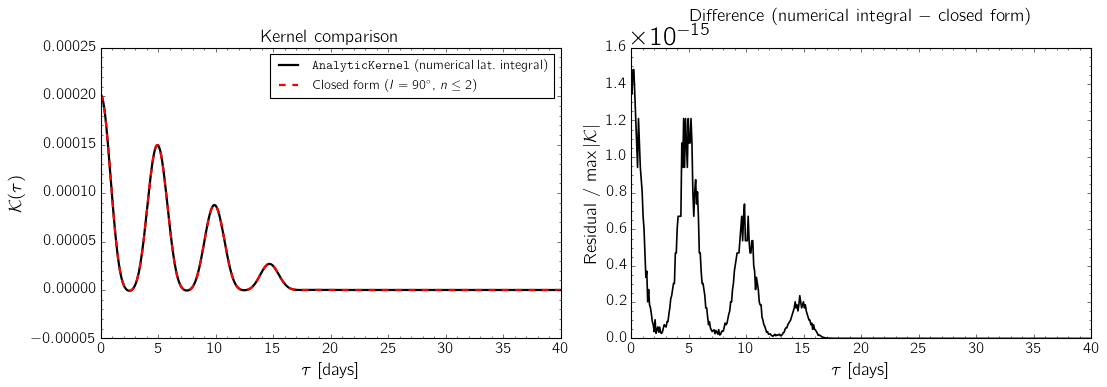

max |numerical - closed form| / max |K| = 1.48e-15


In [11]:
from spotgp.analytic_kernel import AnalyticKernel
from spotgp.envelope import _R_Gamma_symmetric

# Test parameters. The amplitude is sigma_k^2 = Ndot_spot (1 - f_spot)^2 alpha_max^4 (Eq. sigma_k_cspot),
# with Ndot_spot = nspot_rate in spots/day.
hparam = dict(peq=5.0, kappa=0.0, inc=np.pi / 2, lspot=15.0, tau_spot=3.0,
              nspot_rate=1.0, fspot=0.0, alpha_max=0.1)
sigma_k_val = np.sqrt(hparam['nspot_rate']) * (1 - hparam['fspot']) * hparam['alpha_max']**2

# Latitude integral over the paper's range, uniform p(Phi), Gauss-Legendre quadrature
ak = AnalyticKernel(hparam, n_harmonics=2, lat_range=(-np.pi / 2, np.pi / 2),
                    quadrature="gauss-legendre")
assert np.isclose(ak.sigma_k, sigma_k_val)
lag = np.linspace(0, 40, 500)
K_numerical = ak.kernel(lag)

# Closed form: Eq. kernel_edgeon_closed from the registry, with R_Gamma from spotgp
R_sym = sp.Symbol('R')
K_closed_fn = sp.lambdify((tau, omega0, sigma_k, R_sym),
                          K_edgeon_paper.subs(R_Gamma(tau), R_sym), "numpy")
R_G = np.asarray(_R_Gamma_symmetric(lag, hparam['lspot'], hparam['tau_spot']))
w0 = 2 * np.pi / hparam['peq']
K_closed = K_closed_fn(lag, w0, sigma_k_val, R_G)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(lag, K_numerical, 'k-', lw=2, label=r'\texttt{AnalyticKernel} (numerical lat.\ integral)')
ax.plot(lag, K_closed, 'r--', lw=2, label=r'Closed form ($I=90^\circ$, $n\leq 2$)')
ax.set_xlabel(r'$\tau$ [days]', fontsize=16)
ax.set_ylabel(r'$\mathcal{K}(\tau)$', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(labelsize=14)
ax.set_title('Kernel comparison', fontsize=16)
ax.minorticks_on()

ax = axes[1]
ax.plot(lag, (K_numerical - K_closed) / np.max(np.abs(K_closed)), 'k-', lw=1.5)
ax.set_xlabel(r'$\tau$ [days]', fontsize=16)
ax.set_ylabel(r'Residual / $\max|\mathcal{K}|$', fontsize=16)
ax.set_title('Difference (numerical integral $-$ closed form)', fontsize=16, pad=24)
ax.tick_params(labelsize=14)
ax.minorticks_on()
ax.axhline(0, color='gray', lw=0.5)

fig.tight_layout()
plt.show()

max_rel = np.max(np.abs(K_numerical - K_closed)) / np.max(np.abs(K_closed))
print(f"max |numerical - closed form| / max |K| = {max_rel:.2e}")
assert max_rel < 1e-10

## Summary

### Closed-form kernel for $I = 90°$, $\kappa = 0$, uniform $p(\Phi) = 1/\pi$ on $[-\pi/2, \pi/2]$, truncated to $n \leq 2$ (Eq. `eq:kernel_edgeon_closed`):

$$\boxed{\mathcal{K}(\tau) = \sigma_k^2 \, R_\Gamma(\tau)\left[\frac{1}{2\pi^2} + \frac{1}{16}\cos(\omega_0\tau) + \frac{1}{9\pi^2}\cos(2\omega_0\tau)\right]}$$

with $\sigma_k^2 = \dot N_{\rm spot}(1-f_{\rm spot})^2\alpha_{\max}^4$ (Eq. `eq:sigma_k_cspot`), where the three coefficients are:

| $n$ | $g_n$ | $\langle\|c_n\|^2\rangle_\Phi = g_n^2/2$ | Decimal |
|-----|--------|-------------------------------|---------|
| 0 | $1/\pi$ | $1/(2\pi^2)$ | 0.05066 |
| 1 | $1/4$ | $1/32$ | 0.03125 |
| 2 | $1/(3\pi)$ | $1/(18\pi^2)$ | 0.00563 |

At $I=90°$, $b_1 = \cos\Phi \ge 0$ at every latitude, so every spot is visible for half a rotation, $c_n = g_n\cos\Phi$, and $\frac{1}{\pi}\int_{-\pi/2}^{\pi/2}\cos^2\Phi\,d\Phi = \frac12$ gives $\langle|c_n|^2\rangle_\Phi = g_n^2/2$. spotgp's `AnalyticKernel`, which integrates over latitude numerically on the same range, agrees with this to machine precision.

### General $I$:
- $c_0$ and $c_1$ contain bare $\theta_{\rm vis} = \arccos(-\cot I\tan\Phi)$, preventing elementary integration; $\langle|c_0|^2\rangle_\Phi$ and $\langle|c_1|^2\rangle_\Phi$ must be evaluated numerically (cheap: a 1D quadrature).
- $c_2 = b_1\sin^3\theta_{\rm vis}/(3\pi)$ is purely algebraic (all $\theta_{\rm vis}$ appear inside sin/cos) and vanishes outside the band $|\Phi| < I$, and its latitude average is elementary:
$$\langle|c_2|^2\rangle_\Phi = \frac{I\,(1 - 6\cos^2 I) + \tfrac{1}{3}\sin I\cos I\,(3 + 16\cos^2 I - 4\cos^4 I)}{9\pi^3\sin^4 I}, \qquad 0 < I \le \pi/2,$$
which reduces to $1/(18\pi^2)$ at $I = \pi/2$.
- Pole-on ($I \to 0$): $\langle|c_0|^2\rangle_\Phi \to 1/4$ and $\langle|c_{n\ge1}|^2\rangle_\Phi \to 0$, so $\mathcal{K}(\tau) \to \sigma_k^2 R_\Gamma(\tau)/4$, as stated after Eq. `eq:cn_inc`.

## Analytic $R_\Gamma(\tau)$ (Appendix `app:acf_trapezoid`)

$R_\Gamma(\tau)$ is the autocorrelation of the normalized squared envelope $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$ (Eq. `eq:Gamma_piecewise`), a plateau of duration $\ell = \ell_{\rm spot}$ with parabolic ramps of duration $\tau_{\rm s} = \tau_{\rm spot}$. By the Wiener–Khinchin theorem (Eq. `eq:wk`), with $S_\Gamma(\omega) = |\hat\Gamma(\omega)|^2$ and $\hat\Gamma$ real and even:
$$R_\Gamma(\tau) = \frac{1}{2\pi}\int_{-\infty}^{\infty} S_\Gamma(\omega)\,e^{i\omega\tau}\,d\omega = \frac{1}{\pi}\int_0^\infty \hat{\Gamma}(\omega)^2 \cos(\omega\tau)\,d\omega$$

where (Eq. `eq:Gamma_hat`) $\hat{\Gamma}(\omega) = \frac{4}{\tau_{\rm s}^2\omega^3}\left[\tau_{\rm s}\omega\cos\!\left(\frac{\omega\ell}{2}\right) + \sin\!\left(\frac{\omega\ell}{2}\right) - \sin\!\left(\frac{\omega\ell}{2} + \omega\tau_{\rm s}\right)\right]$.

Let's see if sympy can evaluate this integral in closed form.

Γ̂(ω) (Eq. Gamma_hat) =


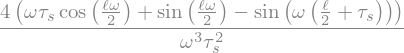

In [12]:
w = eqs.omega      # angular frequency
t = eqs.tau        # lag
ell = eqs.ell      # plateau duration ell = ell_spot
ts = eqs.tau_s     # ramp duration tau_s = tau_spot

# Gamma_hat(omega) of the normalized squared trapezoid
Gamma_hat = (4 / (ts**2 * w**3)) * (
    ts * w * cos(w * ell / 2)
    + sin(w * ell / 2)
    - sin(w * ell / 2 + w * ts)
)
assert simplify(Gamma_hat - eqs.get("eq:Gamma_hat").expr) == 0

Gamma_hat_simplified = simplify(Gamma_hat)
print("Γ̂(ω) (Eq. Gamma_hat) =")
display(Gamma_hat_simplified)

In [13]:
# Expand Gamma_hat^2 * cos(omega*tau) and try to integrate.
# First, expand Gamma_hat^2 using product-to-sum identities.

Gh_sq = sp.expand_trig(sp.expand(Gamma_hat**2))
print(f"Γ̂(ω)² has {len(Gh_sq.as_ordered_terms())} terms after expansion")
print()

# Each term in Gh_sq is of the form: (const / w^p) * trig(w * q)
# where trig is sin or cos and q is a combination of ell, ts.
# After multiplying by cos(w*t), product-to-sum gives terms like:
#   (const / w^p) * cos(w*(q ± t))  or  sin(w*(q ± t))

# Try the full integral directly first (with a timeout)
import signal

class IntegrationTimeout(BaseException):
    """Raised by the alarm. A BaseException, so that sympy's internal `except Exception` cannot swallow it."""

def timeout_handler(signum, frame):
    raise IntegrationTimeout()

print("Attempting full R_Γ integral with sympy (20 s timeout)...")
signal.signal(signal.SIGALRM, timeout_handler)
signal.alarm(20)
try:
    R_Gamma_full = integrate(Gh_sq * cos(w * t), (w, 0, oo)) / pi
    signal.alarm(0)
    R_Gamma_full = simplify(R_Gamma_full)
    print("Success!")
    display(Math(rf"R_\Gamma(\tau) = {latex(R_Gamma_full)}"))
except IntegrationTimeout:
    print("Timed out. Will try term-by-term approach.")
finally:
    signal.alarm(0)

Γ̂(ω)² has 6 terms after expansion

Attempting full R_Γ integral with sympy (20 s timeout)...


Timed out. Will try term-by-term approach.


### Term-by-term approach

$\hat{\Gamma}(\omega)^2$ expands into a sum of terms of the form $\frac{C}{\omega^p}\,\mathrm{trig}(\omega q)$ with $p \in \{4, 5, 6\}$. After multiplying by $\cos(\omega\tau)$ and using product-to-sum identities, each term becomes

$$\int_0^\infty \frac{\cos(a\omega)}{\omega^p}\,d\omega \quad \text{or} \quad \int_0^\infty \frac{\sin(a\omega)}{\omega^p}\,d\omega.$$

Only $\int_0^\infty \frac{\sin(a\omega)}{\omega}\,d\omega = \frac{\pi}{2}\,\mathrm{sgn}(a)$ converges on its own; for higher $p$ each integral diverges at $\omega \to 0$ and only the full sum converges (since $\hat\Gamma(0)$ is finite). Their Hadamard finite parts are
- $\int_0^\infty \frac{\cos(a\omega)}{\omega^{2k}}\,d\omega \to \frac{(-1)^{k}\pi\, |a|^{2k-1}}{2(2k-1)!}$
- $\int_0^\infty \frac{\sin(a\omega)}{\omega^{2k+1}}\,d\omega \to \frac{(-1)^k\pi\, a^{2k}}{2(2k)!}\,\mathrm{sgn}(a)$

Let's expand and see whether sympy can integrate term by term.

B(ω)² expanded:


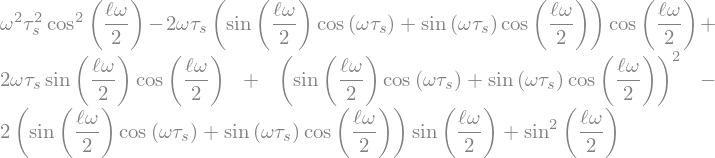


(6 terms)


In [14]:
# Define the bracket term B(w) so that Gamma_hat = (4 / (ts^2 * w^3)) * B(w)
# Then Gamma_hat^2 = 16 / (ts^4 * w^6) * B(w)^2

B = ts * w * cos(w * ell / 2) + sin(w * ell / 2) - sin(w * ell / 2 + w * ts)

# Expand B^2 using product-to-sum identities
B_sq = sp.expand_trig(sp.expand(B**2))
print("B(ω)² expanded:")
display(B_sq)
print(f"\n({len(B_sq.as_ordered_terms())} terms)")

B² collected by powers of ω:


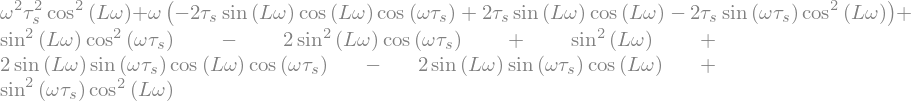

In [15]:
# R_Gamma(tau) = (1/pi) * int_0^inf [16 / (ts^4 * w^6)] * B(w)^2 * cos(w*t) dw
#             = 16 / (pi * ts^4) * int_0^inf B(w)^2 * cos(w*t) / w^6 dw
#
# Strategy: expand B^2 * cos(w*t) into individual terms of the form
#   coeff * trig(w * arg) / w^p
# where p is 4, 5, or 6, and trig is sin or cos.

# B^2 has terms with w^2 * cos^2(...), w * cos(...)*sin(...), sin^2(...)
# Dividing by w^6 gives terms with w^{-4}, w^{-5}, w^{-6}

# Write B with the half-plateau L = ell/2 as shorthand:
# B = ts*w*cos(w*L) + sin(w*L) - sin(w*L + w*ts)
L = sp.Symbol('L', positive=True)  # L = ell/2

B_L = ts * w * cos(w * L) + sin(w * L) - sin(w * (L + ts))
B_L_sq = sp.expand(B_L**2)

# Convert all products of trig functions to sums using product-to-sum
B_L_sq_trig = sp.expand_trig(B_L_sq)

# Now collect by powers of w
from sympy import collect, Wild
B_collected = collect(sp.expand(B_L_sq_trig), w)
print("B² collected by powers of ω:")
display(B_collected)

Piece 1 (from w² term, gives 1/w⁴):


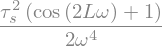


Piece 2 (from w¹ cross terms, gives 1/w⁵):


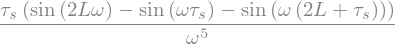


Piece 3 (from w⁰ term, gives 1/w⁶):


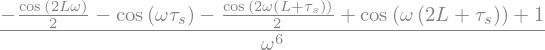


Verification (should be 0): 0


In [16]:
# Separate B^2 into its w^2, w^1, w^0 parts.

# B = ts*w*cos(wL) + sin(wL) - sin(w(L+ts))
# B^2 = ts^2*w^2*cos^2(wL)                         [w^2 piece]
#      + 2*ts*w*cos(wL)*[sin(wL) - sin(w(L+ts))]   [w^1 piece]
#      + [sin(wL) - sin(w(L+ts))]^2                 [w^0 piece]

# Piece 1: ts^2*w^2*cos^2(wL) / w^6 = ts^2*cos^2(wL)/w^4
#   = ts^2/(2*w^4) * [1 + cos(2wL)]
p1 = ts**2 / 2 * (1 + cos(2*w*L)) / w**4

# Piece 2: 2*ts*w*cos(wL)*[sin(wL) - sin(w*(L+ts))] / w^6
# cos(wL)*sin(wL) = sin(2wL)/2
# cos(wL)*sin(w(L+ts)) = [sin(w(2L+ts)) + sin(w*ts)] / 2
p2 = ts / w**5 * (sin(2*w*L) - sin(w*(2*L+ts)) - sin(w*ts))

# Piece 3: [sin(wL) - sin(w(L+ts))]^2 / w^6
# sin^2(wL) = (1 - cos(2wL))/2
# sin^2(w(L+ts)) = (1 - cos(2w(L+ts)))/2
# sin(wL)*sin(w(L+ts)) = [cos(w*ts) - cos(w*(2L+ts))]/2
p3_num = (sp.Rational(1,2) - cos(2*w*L)/2
          + sp.Rational(1,2) - cos(2*w*(L+ts))/2
          - cos(w*ts) + cos(w*(2*L+ts)))
p3 = p3_num / w**6

print("Piece 1 (from w² term, gives 1/w⁴):")
display(p1)
print("\nPiece 2 (from w¹ cross terms, gives 1/w⁵):")
display(p2)
print("\nPiece 3 (from w⁰ term, gives 1/w⁶):")
display(p3)

# Verify: the sum should equal B^2/w^6
check = sp.expand_trig(sp.expand((p1 + p2 + p3) * w**6 - B_L_sq))
print(f"\nVerification (should be 0): {simplify(check)}")

B(ω) Taylor expansion around ω=0:


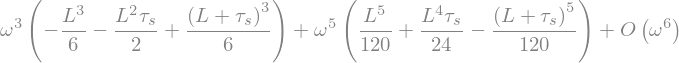

B²/ω⁶ Taylor expansion (should be finite at ω=0):


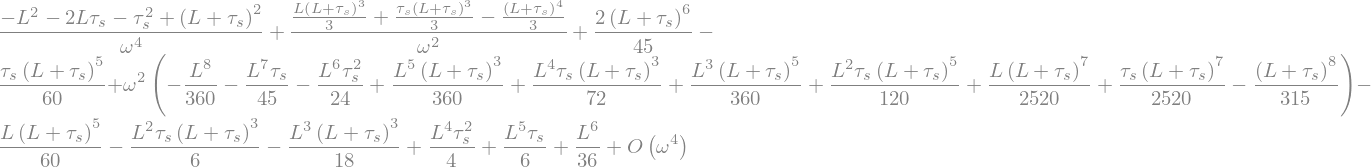

In [17]:
# The individual integrals diverge at w -> 0 (see the finite parts above); only the full
# sum converges, because B(w) = O(w^3) as w -> 0, so B^2/w^6 stays finite.
# Verify the small-w behavior.

# B(w) as w -> 0:
B_series = sp.series(B_L, w, 0, n=6)
print("B(ω) Taylor expansion around ω=0:")
display(B_series)
print()

# B^2/w^6 as w -> 0:
B_sq_over_w6_series = sp.series(B_L_sq / w**6, w, 0, n=4)
print("B²/ω⁶ Taylor expansion (should be finite at ω=0):")
display(B_sq_over_w6_series)

In [18]:
# Leading order of B:
# B = ts*w*cos(wL) + sin(wL) - sin(w(L+ts))
# At w=0: B(0) = 0 + 0 - 0 = 0
# B'(0) = ts + L - (L+ts) = 0
# The first nonzero coefficient is at w^3: B = ts^2 (3L + ts) w^3 / 6 + O(w^5), so
# Gamma_hat(0) = 4/ts^2 * ts^2 (3L + ts)/6 = 2L + 2 ts/3 = ell + 2 tau_s/3 = int Gamma dt.

B_taylor = sp.series(B_L, w, 0, n=8).removeO()
print("B(ω) =", B_taylor)
print()

# Extract coefficients
for k in range(8):
    coeff = B_taylor.coeff(w, k)
    if coeff != 0:
        print(f"  w^{k} coefficient: {simplify(coeff)}")

assert simplify(4 / ts**2 * B_taylor.coeff(w, 3) - (2 * L + 2 * ts / 3)) == 0

B(ω) = omega**7*(-L**7/5040 - L**6*tau_s/720 + (L + tau_s)**7/5040) + omega**5*(L**5/120 + L**4*tau_s/24 - (L + tau_s)**5/120) + omega**3*(-L**3/6 - L**2*tau_s/2 + (L + tau_s)**3/6)

  w^3 coefficient: tau_s**2*(3*L + tau_s)/6
  w^5 coefficient: L**5/120 + L**4*tau_s/24 - (L + tau_s)**5/120
  w^7 coefficient: -L**7/5040 - L**6*tau_s/720 + (L + tau_s)**7/5040


In [19]:
# Since individual terms in B^2/w^6 have divergent integrals,
# let's see whether sympy can integrate the terms of the integrand B^2*cos(w*t)/w^6
# one at a time, after combining trig products.

# Multiply B^2/w^6 by cos(w*t) and fully expand using product-to-sum
integrand_full = B_L_sq * cos(w * t) / w**6
integrand_expanded = sp.expand_trig(sp.expand(integrand_full))

# Collect all terms
terms = integrand_expanded.as_ordered_terms()
print(f"Total terms in integrand: {len(terms)}")
print()

# Try integrating each term individually (5 s per term)
results = []
failed = []
signal.signal(signal.SIGALRM, timeout_handler)

for i, term in enumerate(terms):
    signal.alarm(5)
    try:
        res = integrate(term, (w, 0, oo))
        signal.alarm(0)
        results.append((term, res))
        print(f"  Term {i+1}: ✓")
    except IntegrationTimeout:
        signal.alarm(0)
        failed.append((i, term))
        print(f"  Term {i+1}: timeout")
    except Exception as e:
        signal.alarm(0)
        failed.append((i, term))
        print(f"  Term {i+1}: {type(e).__name__}")

signal.alarm(0)
print(f"\nSuccessful: {len(results)}, Failed: {len(failed)}")

Total terms in integrand: 6



  Term 1: timeout


  Term 2: timeout


  Term 3: timeout


  Term 4: timeout


  Term 5: timeout


  Term 6: timeout

Successful: 0, Failed: 6


In [20]:
# Term-by-term integration over omega does not work because of the divergences.
# Instead, compute R_Gamma directly in the time domain. It is the autocorrelation of Gamma(t),
# i.e. the convolution of Gamma(t) with Gamma(-t) = Gamma(t) (Gamma is even):
#
#   R_Gamma(tau) = int_{-inf}^{inf} Gamma(s) Gamma(s + tau) ds
#
# The normalized squared trapezoid (Eq. Gamma_piecewise), with L = ell/2 and S = L + tau_s:
#   Gamma(t) = 1                         for |t| <= L          (plateau)
#   Gamma(t) = ((S - |t|) / tau_s)^2     for L < |t| <= S      (parabolic ramp)
#   Gamma(t) = 0                         for |t| > S
#
# It is piecewise polynomial, so R_Gamma(tau) is a piecewise polynomial in tau,
# of degree 5 (the ramps are quadratic), with support tau in [0, 2S] = [0, ell + 2 tau_s].

print("R_Γ(τ) is the autocorrelation of a piecewise-quadratic function.")
print("It will be a piecewise polynomial of degree ≤ 5 in τ.")
print("Support: τ ∈ [0, 2(ℓ/2 + τ_s)] = [0, ℓ + 2τ_s]")
print()
print("Computing via direct convolution integral...")

R_Γ(τ) is the autocorrelation of a piecewise-quadratic function.
It will be a piecewise polynomial of degree ≤ 5 in τ.
Support: τ ∈ [0, 2(ℓ/2 + τ_s)] = [0, ℓ + 2τ_s]

Computing via direct convolution integral...


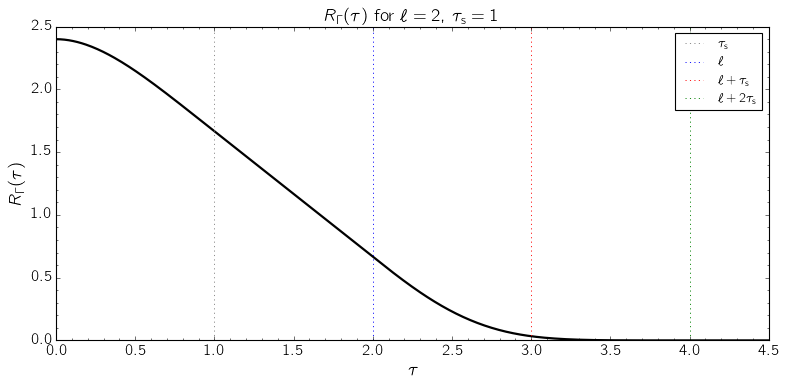

R_Γ(0) = 2.400000  (expected ∫Γ² ds = ℓ + 2τ_s/5 = 2.400000)


In [21]:
# Numerical R_Gamma by direct convolution, for checking the symbolic result.
import numpy as np

def Gamma_numpy(t_arr, ell_n, ts_n):
    """Normalized squared trapezoid Gamma(t) = alpha^2(t) / alpha_max^2 (Eq. Gamma_piecewise)."""
    abs_t = np.abs(t_arr)
    return np.where(abs_t <= ell_n / 2, 1.0,
                    np.where(abs_t <= ell_n / 2 + ts_n, ((ell_n / 2 + ts_n - abs_t) / ts_n)**2, 0.0))

def R_Gamma_numerical(lag_val, ell_n, ts_n, ns=20001):
    """R_Gamma(lag) = int Gamma(s) Gamma(s + lag) ds, by the trapezoid rule."""
    S_n = ell_n / 2 + ts_n
    s_grid = np.linspace(-S_n - 0.1, S_n + 0.1, ns)
    return np.trapezoid(Gamma_numpy(s_grid, ell_n, ts_n) * Gamma_numpy(s_grid + lag_val, ell_n, ts_n), s_grid)

# Plot R_Gamma for ell = 2, tau_s = 1
ell_n, ts_n = 2.0, 1.0
tau_grid = np.linspace(0, 4.5, 500)
R_vals = np.array([R_Gamma_numerical(tv, ell_n, ts_n) for tv in tau_grid])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tau_grid, R_vals, 'k-', lw=2)
ax.set_xlabel(r'$\tau$', fontsize=16)
ax.set_ylabel(r'$R_\Gamma(\tau)$', fontsize=16)
ax.set_title(r'$R_\Gamma(\tau)$ for $\ell=2$, $\tau_{\rm s}=1$', fontsize=16)
ax.axvline(ts_n, color='gray', ls=':', lw=0.8, label=r'$\tau_{\rm s}$')
ax.axvline(ell_n, color='blue', ls=':', lw=0.8, label=r'$\ell$')
ax.axvline(ell_n + ts_n, color='red', ls=':', lw=0.8, label=r'$\ell+\tau_{\rm s}$')
ax.axvline(ell_n + 2 * ts_n, color='green', ls=':', lw=0.8, label=r'$\ell+2\tau_{\rm s}$')
ax.legend(fontsize=12)
ax.tick_params(labelsize=14)
ax.minorticks_on()
fig.tight_layout()
plt.show()

# R_Gamma(0) = int Gamma^2 ds = ell + 2 * int_0^{tau_s} (u / tau_s)^4 du = ell + 2 tau_s / 5
print(f"R_Γ(0) = {R_vals[0]:.6f}  (expected ∫Γ² ds = ℓ + 2τ_s/5 = {ell_n + 2 * ts_n / 5:.6f})")
assert abs(R_vals[0] - (ell_n + 2 * ts_n / 5)) < 1e-6

In [22]:
# Direct symbolic computation of R_Gamma(tau) via the convolution, with sympy's Piecewise integration.
# Gamma(s) is piecewise on [-S, S] where S = L + ts, with breakpoints at +-L, and the overlap of
# Gamma(s) and Gamma(s + T) (lag T >= 0) is s in [-S, S - T].

s = sp.Symbol('s', real=True)
T = sp.Symbol('T', positive=True)   # the lag tau during the derivation
S = L + ts                           # half-support of Gamma

Gamma_s = sp.Piecewise(
    (1, (s >= -L) & (s <= L)),
    (((S - s)/ts)**2, (s > L) & (s <= S)),
    (((S + s)/ts)**2, (s >= -S) & (s < -L)),
    (0, True)
)

Gamma_sT = Gamma_s.subs(s, s + T)

# The product
product = Gamma_s * Gamma_sT

# Let sympy integrate it for specific values first: L = 2 (ell = 4), tau_s = 1
print("Computing R_Γ symbolically with Piecewise integration, for ℓ = 4, τ_s = 1...")
product_specific = product.subs({L: 2, ts: 1})

signal.signal(signal.SIGALRM, timeout_handler)
signal.alarm(60)
try:
    R_specific = integrate(product_specific, (s, -3, 3 - T))
    signal.alarm(0)
    R_specific = sp.simplify(R_specific)
    print("Success for ℓ=4, τ_s=1 (a Piecewise of Min/Max terms; not shown). Values vs Eq. R_Gamma_closed:")
    R_paper_specific = eqs.get("eq:R_Gamma_closed").expr.subs({eqs.ell: 4, eqs.tau_s: 1})
    for T_val in [0.5, 2.0, 4.5, 5.5, 7.0]:
        r_pw, r_paper = float(R_specific.subs(T, T_val)), float(R_paper_specific.subs(eqs.tau, T_val))
        print(f"  τ = {T_val}: Piecewise integral = {r_pw:.6f},  Eq. R_Gamma_closed = {r_paper:.6f}")
        assert abs(r_pw - r_paper) < 1e-12
except IntegrationTimeout:
    print("Timed out after 60s. Piecewise integration too slow for sympy.")
finally:
    signal.alarm(0)
print("Next: the general (symbolic ℓ, τ_s) result, by splitting the integral into intervals by hand.")

Computing R_Γ symbolically with Piecewise integration, for ℓ = 4, τ_s = 1...


Success for ℓ=4, τ_s=1 (a Piecewise of Min/Max terms; not shown). Values vs Eq. R_Gamma_closed:
  τ = 0.5: Piecewise integral = 4.147917,  Eq. R_Gamma_closed = 4.147917
  τ = 2.0: Piecewise integral = 2.666667,  Eq. R_Gamma_closed = 2.666667
  τ = 4.5: Piecewise integral = 0.230208,  Eq. R_Gamma_closed = 0.230208
  τ = 5.5: Piecewise integral = 0.001042,  Eq. R_Gamma_closed = 0.001042
  τ = 7.0: Piecewise integral = 0.000000,  Eq. R_Gamma_closed = 0.000000
Next: the general (symbolic ℓ, τ_s) result, by splitting the integral into intervals by hand.


Computing R_Γ(T) for T ∈ [0, τ_s] (assuming τ_s ≤ ℓ):


I1 (ramp × ramp, left):


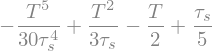


I2 (ramp × plateau, left):


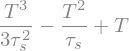


I3 (plateau × plateau):



I4 (plateau × ramp, right):


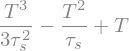


I5 (ramp × ramp, right):


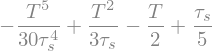

In [23]:
# Manual approach: compute R_Gamma(T) by splitting the convolution integral
# into sub-intervals where both Gamma(s) and Gamma(s+T) have known polynomial forms.
#
# Gamma(u), normalized (peak 1):
#   ramp_neg:  u in [-S, -L]  => ((u + S)/ts)^2
#   plateau:   u in [-L, L]   => 1
#   ramp_pos:  u in [L, S]    => ((S - u)/ts)^2
#   zero:      otherwise
#
# For the convolution R(T) = int Gamma(s) Gamma(s+T) ds, T >= 0:
# Gamma(s) has breakpoints at s = -S, -L, L, S
# Gamma(s+T) has breakpoints at s = -S-T, -L-T, L-T, S-T
#
# Integration region: s in [-S, S-T]
#
# For 0 <= T <= ts (and ts <= ell = 2L, so that L - T >= -L):
# Sorted breakpoints in [-S, S-T]:
#   -S, -L-T, -L, L-T, L, S-T
#
# Sub-intervals and (Gamma(s), Gamma(s+T)) regions:
#   [-S, -L-T]:     ramp_neg, ramp_neg    (both in ramp)
#   [-L-T, -L]:     ramp_neg, plateau
#   [-L, L-T]:      plateau,  plateau     (both in plateau)
#   [L-T, L]:       plateau,  ramp_pos
#   [L, S-T]:       ramp_pos, ramp_pos    (both in ramp)

# Gamma expressions in each region:
ramp_neg_s = ((s + S)/ts)**2        # for s in [-S, -L]
plateau_s  = sp.Integer(1)          # for s in [-L, L]
ramp_pos_s = ((S - s)/ts)**2        # for s in [L, S]

ramp_neg_st = ((s + T + S)/ts)**2   # for s+T in [-S, -L], i.e., s in [-S-T, -L-T]
plateau_st  = sp.Integer(1)         # for s+T in [-L, L], i.e., s in [-L-T, L-T]
ramp_pos_st = ((S - s - T)/ts)**2   # for s+T in [L, S], i.e., s in [L-T, S-T]

print("Computing R_Γ(T) for T ∈ [0, τ_s] (assuming τ_s ≤ ℓ):")
print("=" * 60)

# Sub-interval 1: s in [-S, -L-T], both ramp_neg
I1 = integrate(ramp_neg_s * ramp_neg_st, (s, -S, -L-T))
I1 = simplify(I1)
print("I1 (ramp × ramp, left):")
display(I1)

# Sub-interval 2: s in [-L-T, -L], ramp_neg × plateau
I2 = integrate(ramp_neg_s * plateau_st, (s, -L-T, -L))
I2 = simplify(I2)
print("\nI2 (ramp × plateau, left):")
display(I2)

# Sub-interval 3: s in [-L, L-T], both plateau
I3 = integrate(plateau_s * plateau_st, (s, -L, L-T))
I3 = simplify(I3)
print("\nI3 (plateau × plateau):")
display(I3)

# Sub-interval 4: s in [L-T, L], plateau × ramp_pos
I4 = integrate(plateau_s * ramp_pos_st, (s, L-T, L))
I4 = simplify(I4)
print("\nI4 (plateau × ramp, right):")
display(I4)

# Sub-interval 5: s in [L, S-T], both ramp_pos
I5 = integrate(ramp_pos_s * ramp_pos_st, (s, L, S-T))
I5 = simplify(I5)
print("\nI5 (ramp × ramp, right):")
display(I5)

R_Γ(T) for T ∈ [0, τ_s]:


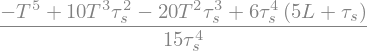


As polynomial in T:
  T^5: -1/(15*tau_s**4)
  T^3: 2/(3*tau_s**2)
  T^2: -4/(3*tau_s)
  T^0: 2*L + 2*tau_s/5

R_Γ(0) = 2*L + 2*tau_s/5
Expected: 2L + 2τ_s/5 = ℓ + 2τ_s/5
Match: True


In [24]:
# Total R_Gamma for T in [0, ts]:
R_interval_1 = simplify(I1 + I2 + I3 + I4 + I5)
print("R_Γ(T) for T ∈ [0, τ_s]:")
display(R_interval_1)
print()

# Collect by powers of T
R_poly = sp.Poly(sp.expand(R_interval_1), T)
print("As polynomial in T:")
for power, coeff in sorted(R_poly.as_dict().items(), reverse=True):
    print(f"  T^{power[0]}: {simplify(coeff)}")

# Check at T=0: R_Gamma(0) = int Gamma^2 ds = 2L + 2 * int_L^S ((S-s)/ts)^4 ds = 2L + 2 ts/5
R_at_0 = R_interval_1.subs(T, 0)
expected_R0 = 2*L + 2*ts/5
print(f"\nR_Γ(0) = {simplify(R_at_0)}")
print(f"Expected: 2L + 2τ_s/5 = ℓ + 2τ_s/5")
print(f"Match: {simplify(R_at_0 - expected_R0) == 0}")
assert simplify(R_at_0 - expected_R0) == 0

For T ∈ [τ_s, ℓ] (assuming τ_s ≤ ℓ):
Sub-intervals: [-S,-L], [-L,L-T], [L-T,S-T]

J1 (ramp_neg × plateau):



J2 (plateau × plateau):



J3 (plateau × ramp_pos):



R_Γ(T) for T ∈ [τ_s, ℓ]:


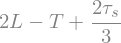

In [25]:
# Now compute R_Gamma for the remaining lag intervals (all need only ts <= ell = 2L).
# For T > ts, the ramp-ramp overlaps vanish:
#   at s = -S, s + T = T - S > -L, so Gamma(s+T) is already on the plateau (no ramp_neg x ramp_neg);
#   at s = L,  s + T = L + T > S,  so Gamma(s+T) = 0 (no ramp_pos x ramp_pos).
#
# For T in [ts, 2L], the integration range [-S, S-T] has breakpoints
#   -S, -L, L-T, S-T    (-L <= L-T since T <= 2L; S-T <= L since T >= ts)
#
# Sub-intervals:
#   [-S, -L]:     Gamma(s) = ramp_neg;  s+T in [T-S, T-L], T-S >= -L and T-L <= L  => plateau
#   [-L, L-T]:    Gamma(s) = plateau;   s+T in [T-L, L]                            => plateau
#   [L-T, S-T]:   Gamma(s) = plateau (S-T <= L);  s+T in [L, S]                    => ramp_pos

print("For T ∈ [τ_s, ℓ] (assuming τ_s ≤ ℓ):")
print("Sub-intervals: [-S,-L], [-L,L-T], [L-T,S-T]")
print()

# Sub-interval 1: s in [-S, -L], ramp_neg × plateau
J1 = integrate(ramp_neg_s * plateau_st, (s, -S, -L))
J1 = simplify(J1)
print("J1 (ramp_neg × plateau):")
display(J1)

# Sub-interval 2: s in [-L, L-T], plateau × plateau
J2 = integrate(plateau_s * plateau_st, (s, -L, L-T))
J2 = simplify(J2)
print("\nJ2 (plateau × plateau):")
display(J2)

# Sub-interval 3: s in [L-T, S-T], plateau × ramp_pos
J3 = integrate(plateau_s * ramp_pos_st, (s, L-T, S-T))
J3 = simplify(J3)
print("\nJ3 (plateau × ramp_pos):")
display(J3)

R_interval_2 = simplify(J1 + J2 + J3)
print("\nR_Γ(T) for T ∈ [τ_s, ℓ]:")
display(R_interval_2)

For T ∈ [ℓ, ℓ+τ_s] (assuming τ_s ≤ ℓ):

K1 (ramp_neg × plateau):


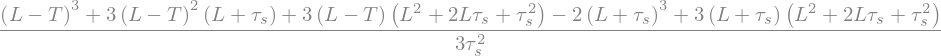


K2 (ramp_neg × ramp_pos):


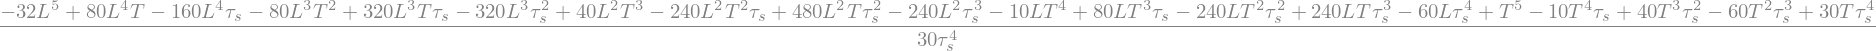


K3 (plateau × ramp_pos):


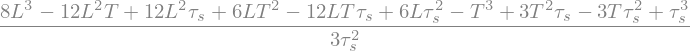


R_Γ(T) for T ∈ [ℓ, ℓ+τ_s]:


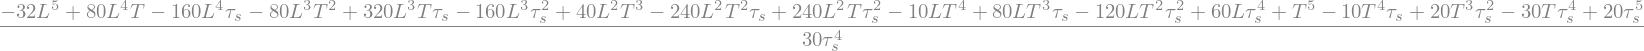

In [26]:
# For T in [2L, 2L+ts]:
# The plateau-plateau overlap vanishes. Integration range: [-S, S-T], with S-T in [-L, ts-L].
#
# Breakpoints: -S, L-T, -L, S-T
#   L-T in [-S, -L] for T in [2L, 2L+ts]: Gamma(s+T) leaves the plateau there
#   -L <= S-T since T <= 2L + ts
#
# Sub-intervals:
#   [-S, L-T]:   Gamma(s) = ramp_neg;  s+T in [T-S, L], T-S >= L - ts >= -L    => plateau
#   [L-T, -L]:   Gamma(s) = ramp_neg;  s+T in [L, T-L], T-L in [L, S]          => ramp_pos
#   [-L, S-T]:   Gamma(s) = plateau;   s+T in [T-L, S]                         => ramp_pos

print("For T ∈ [ℓ, ℓ+τ_s] (assuming τ_s ≤ ℓ):")
print()

# Sub-interval 1: s in [-S, L-T], ramp_neg × plateau
K1 = integrate(ramp_neg_s * plateau_st, (s, -S, L-T))
K1 = simplify(K1)
print("K1 (ramp_neg × plateau):")
display(K1)

# Sub-interval 2: s in [L-T, -L], ramp_neg × ramp_pos
K2 = integrate(ramp_neg_s * ramp_pos_st, (s, L-T, -L))
K2 = simplify(K2)
print("\nK2 (ramp_neg × ramp_pos):")
display(K2)

# Sub-interval 3: s in [-L, S-T], plateau × ramp_pos
K3 = integrate(plateau_s * ramp_pos_st, (s, -L, S-T))
K3 = simplify(K3)
print("\nK3 (plateau × ramp_pos):")
display(K3)

R_interval_3 = simplify(K1 + K2 + K3)
print("\nR_Γ(T) for T ∈ [ℓ, ℓ+τ_s]:")
display(R_interval_3)

For T ∈ [ℓ+τ_s, ℓ+2τ_s]:



M1 (ramp_neg × ramp_pos, full overlap):


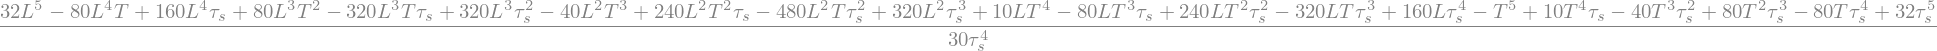


R_Γ(T) for T ∈ [ℓ+τ_s, ℓ+2τ_s]:


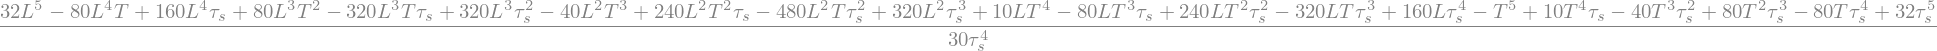

In [27]:
# For T in [2L+ts, 2L+2ts] = [2L+ts, 2S]:
# Integration range: [-S, S-T], with S-T in [-S, -L].
# Both Gamma(s) and Gamma(s+T) are on ramps over the entire overlap:
#   s in [-S, S-T] is on ramp_neg; s+T in [T-S, S], T-S >= L, is on ramp_pos.
# Only interval: [-S, S-T], ramp_neg(s) × ramp_pos(s+T)

print("For T ∈ [ℓ+τ_s, ℓ+2τ_s]:")
print()

M1 = integrate(ramp_neg_s * ramp_pos_st, (s, -S, S-T))
M1 = simplify(M1)
print("M1 (ramp_neg × ramp_pos, full overlap):")
display(M1)

R_interval_4 = M1
print("\nR_Γ(T) for T ∈ [ℓ+τ_s, ℓ+2τ_s]:")
display(R_interval_4)

In [28]:
# Verify all four pieces against the numerical convolution, for ell/2 > tau_s (ell = 4, tau_s = 1)
# and for tau_s < ell < 2 tau_s (ell = 1.5, tau_s = 1), where the derivation's orderings still hold
pieces = [R_interval_1, R_interval_2, R_interval_3, R_interval_4]
labels = ["[0, τ_s]", "[τ_s, ℓ]", "[ℓ, ℓ+τ_s]", "[ℓ+τ_s, ℓ+2τ_s]"]

for ell_n, ts_n, test_lags in [(4.0, 1.0, [0.5, 2.0, 4.5, 5.5]), (1.5, 1.0, [0.5, 1.25, 2.0, 3.0])]:
    print(f"Numerical verification (ℓ={ell_n}, τ_s={ts_n}):")
    print("=" * 60)
    for T_val, label, R_expr in zip(test_lags, labels, pieces):
        R_sym = float(R_expr.subs({T: T_val, L: ell_n / 2, ts: ts_n}))
        R_num = R_Gamma_numerical(T_val, ell_n, ts_n)
        match = abs(R_sym - R_num) < 1e-6
        print(f"  τ={T_val} ({label}): symbolic={R_sym:.6f}, numerical={R_num:.6f}, match={match}")
        assert match
    print()

Numerical verification (ℓ=4.0, τ_s=1.0):
  τ=0.5 ([0, τ_s]): symbolic=4.147917, numerical=4.147917, match=True
  τ=2.0 ([τ_s, ℓ]): symbolic=2.666667, numerical=2.666667, match=True
  τ=4.5 ([ℓ, ℓ+τ_s]): symbolic=0.230208, numerical=0.230208, match=True
  τ=5.5 ([ℓ+τ_s, ℓ+2τ_s]): symbolic=0.001042, numerical=0.001042, match=True

Numerical verification (ℓ=1.5, τ_s=1.0):
  τ=0.5 ([0, τ_s]): symbolic=1.647917, numerical=1.647917, match=True
  τ=1.25 ([τ_s, ℓ]): symbolic=0.916667, numerical=0.916667, match=True
  τ=2.0 ([ℓ, ℓ+τ_s]): symbolic=0.230208, numerical=0.230208, match=True
  τ=3.0 ([ℓ+τ_s, ℓ+2τ_s]): symbolic=0.001042, numerical=0.001042, match=True



### Result in the paper's notation (Eq. `eq:R_Gamma_closed`)

Substituting $L = \ell/2$ and writing the lag as $\tau$ gives the piecewise form of Appendix `app:acf_trapezoid`. Each piece is compared with Eq. `eq:R_Gamma_closed` (and the third with Eq. `eq:P3`) from the equation registry, and the whole function with spotgp's `_R_Gamma_symmetric`.

The derivation above only needs $\tau_{\rm s} \le \ell$ (plateau at least as long as one ramp), which is also the range spotgp enforces; the appendix states the stronger assumption $\ell/2 > \tau_{\rm s}$.

In [29]:
# Final result in the paper's notation: plateau ell = 2L, ramp tau_s, lag tau
to_paper = {L: ell / 2, T: t}
R_pieces = [sp.expand(R.subs(to_paper)) for R in (R_interval_1, R_interval_2, R_interval_3, R_interval_4)]
bounds = [sp.Integer(0), ts, ell, ell + ts, ell + 2 * ts]

def paper_form(expr, i):
    """LaTeX in the appendix's layout: powers of tau with factored coefficients (ascending in the
    first two pieces, descending in P_3), and the last piece as a fifth power."""
    names = dict(symbol_names={ts: r"\tau_{\rm s}"})
    if i == 3:
        return latex(sp.factor(expr), **names)
    coeffs = sp.Poly(expr, t).all_coeffs()[::-1]           # coefficient of tau^k at index k
    terms = [sp.factor(c) * t**k for k, c in enumerate(coeffs) if c != 0]
    if i < 2:
        terms = [ell, sp.expand(terms[0] - ell)] + terms[1:]            # ell + 2 tau_s / 5, ell + 2 tau_s / 3
    else:
        terms = terms[::-1]
    out = latex(terms[0], **names)
    for term in terms[1:]:
        s = latex(term, **names)
        out += " - " + s[1:].lstrip() if s.startswith("-") else " + " + s
    return out

print("CLOSED-FORM R_Γ(τ) for the normalized squared trapezoidal envelope")
print("(valid for τ_s ≤ ℓ, i.e., plateau at least as long as a ramp)")
print("=" * 60)
print()
for i, R in enumerate(R_pieces):
    lo, hi = (latex(b, symbol_names={ts: r"\tau_{\rm s}"}) for b in bounds[i:i + 2])
    display(Math(rf"R_\Gamma(\tau) = {paper_form(R, i)}\qquad {lo} \le \tau \le {hi}"))
    print()
print("  τ > ℓ + 2τ_s:  R_Γ(τ) = 0")
print()

# Compare with Eqs. R_Gamma_closed and P3 from the registry
R_paper = eqs.get("eq:R_Gamma_closed").expr
*branches, (zero_piece, otherwise) = R_paper.args
assert zero_piece == 0 and otherwise == True and len(branches) == 4
for i, ((paper_piece, cond), R) in enumerate(zip(branches, R_pieces)):
    assert simplify(R - paper_piece) == 0, f"piece {i + 1} differs from Eq. R_Gamma_closed"
    upper = cond if cond.lhs == t else cond.reversed   # each branch holds for tau <= its upper end
    assert upper.lhs == t and upper.rhs == bounds[i + 1]
assert simplify(R_pieces[2] - eqs.get("eq:P3").expr) == 0
print("Verified: the four pieces and their breakpoints equal Eq. R_Gamma_closed; the third piece is Eq. P3")

# And spotgp's implementation, on a lag grid past the end of the support
R_paper_fn = sp.lambdify((t, ell, ts), R_paper, "numpy")
for ell_n, ts_n in [(15.0, 3.0), (1.5, 1.0)]:
    lag_grid = np.linspace(0, 1.2 * (ell_n + 2 * ts_n), 1001)
    R_reg = np.array([float(R_paper_fn(lv, ell_n, ts_n)) for lv in lag_grid])
    R_spotgp = np.asarray(_R_Gamma_symmetric(lag_grid, ell_n, ts_n))
    assert np.allclose(R_reg, R_spotgp, rtol=0, atol=1e-12 * ell_n)
print("Verified: spotgp's _R_Gamma_symmetric equals Eq. R_Gamma_closed (ℓ=15, τ_s=3 and ℓ=1.5, τ_s=1)")

CLOSED-FORM R_Γ(τ) for the normalized squared trapezoidal envelope
(valid for τ_s ≤ ℓ, i.e., plateau at least as long as a ramp)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


  τ > ℓ + 2τ_s:  R_Γ(τ) = 0



Verified: the four pieces and their breakpoints equal Eq. R_Gamma_closed; the third piece is Eq. P3
Verified: spotgp's _R_Gamma_symmetric equals Eq. R_Gamma_closed (ℓ=15, τ_s=3 and ℓ=1.5, τ_s=1)
